In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest

In [2]:
conn = sqlite3.connect("../database/air_quality.db")

df = pd.read_sql_query(
    "SELECT * FROM processed_air_quality",
    conn
)

df.tail()

,id,timestamp,aqi,pm2_5,pm10,co,no2,o3,so2,hour,day,weekday
285,286,2026-08-12 20:03:47,5,76.39,86.53,563.66,12.55,84.04,8.55,20,12,Wednesday
286,287,2026-08-12 20:23:58,5,79.12,90.80,627.42,13.80,72.78,8.96,20,12,Wednesday
287,288,2026-08-12 21:03:47,5,79.12,90.80,627.42,13.80,72.78,8.96,21,12,Wednesday
288,289,2026-08-12 22:03:44,5,80.29,93.23,674.34,14.59,62.94,8.88,22,12,Wednesday
289,290,2026-08-13 11:03:48,5,82.49,87.27,707.44,13.01,62.08,8.37,11,13,Thursday


In [3]:
features = [
    "aqi",
    "pm2_5",
    "pm10",
    "co",
    "no2",
    "o3",
    "so2"
]

X = df[features]

In [4]:
#isolation forest model
model = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)

model.fit(X)

IsolationForest(contamination=0.05, random_state=42)

What does contamination=0.05 mean?

It tells the model to expect that approximately 5% of the observations are anomalies.

In [5]:
#predict anomalies
df["anomaly"] = model.predict(X)

In [6]:
#count the number of anomalies
#1 indicates normal data, -1 indicates anomaly
print(df["anomaly"].value_counts())

anomaly
 1    275
-1     15
Name: count, dtype: int64


In [7]:
#show the anomalies
anomalies = df[df["anomaly"] == -1]

anomalies

,id,timestamp,aqi,pm2_5,pm10,co,no2,o3,so2,hour,day,weekday,anomaly
111,112,2026-07-27 23:03:44,5,75.90,94.68,1093.89,25.71,21.69,7.55,23,27,Monday,-1
179,180,2026-08-02 22:03:45,5,79.17,94.95,1078.92,26.55,17.67,6.55,22,2,Sunday,-1
180,181,2026-08-02 23:03:44,5,81.95,97.99,1109.09,25.40,12.95,5.64,23,2,Sunday,-1
209,210,2026-08-05 19:03:48,4,72.95,82.30,1153.78,29.81,9.40,9.92,19,5,Wednesday,-1
248,249,2026-08-09 14:03:44,2,16.13,17.10,263.83,2.64,80.95,2.83,14,9,Sunday,-1
249,250,2026-08-09 15:03:44,2,17.86,18.87,252.61,2.27,86.44,2.82,15,9,Sunday,-1
250,251,2026-08-09 16:03:45,2,19.68,20.92,255.51,2.59,89.86,3.09,16,9,Sunday,-1
269,270,2026-08-11 19:03:59,5,80.98,99.03,839.16,28.25,71.33,12.52,19,11,Tuesday,-1
271,272,2026-08-11 21:06:08,5,89.29,106.16,709.76,17.36,70.41,9.32,21,11,Tuesday,-1
272,273,2026-08-11 22:03:51,5,93.69,113.40,797.66,19.37,58.39,9.41,22,11,Tuesday,-1


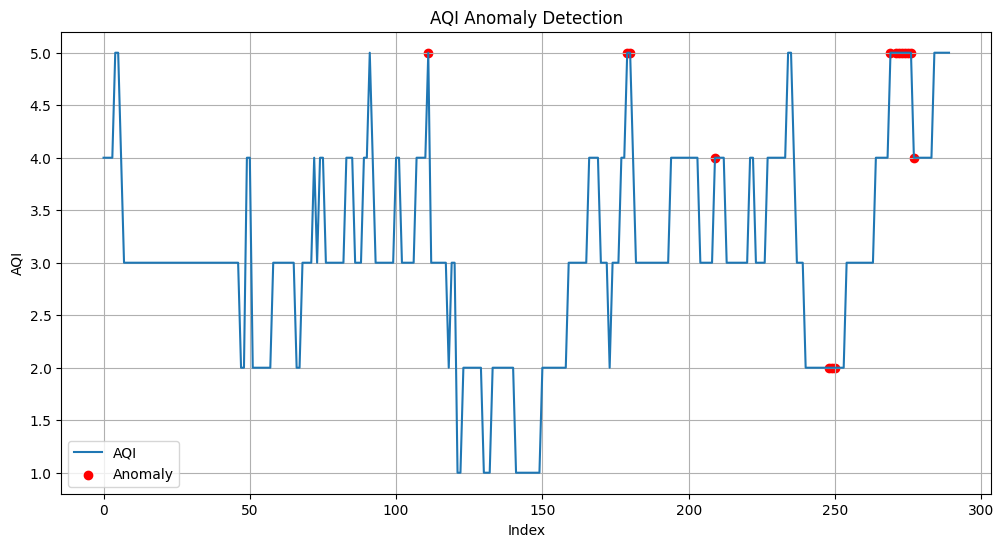

In [8]:
plt.figure(figsize=(12,6))

plt.plot(df.index, df["aqi"], label="AQI")

plt.scatter(
    anomalies.index,
    anomalies["aqi"],
    color="red",
    label="Anomaly"
)

plt.title("AQI Anomaly Detection")

plt.xlabel("Index")

plt.ylabel("AQI")

plt.legend()

plt.grid(True)

plt.show()

In [9]:
df.to_csv(
    "../data/anomaly_results.csv",
    index=False
)

In [10]:
df.to_sql(
    "anomaly_results",
    conn,
    if_exists="replace",
    index=False
)

290

In [11]:
import joblib

joblib.dump(
    model,
    "saved_models/isolation_forest.pkl"
)

['saved_models/isolation_forest.pkl']

In [12]:
model = joblib.load(
    "saved_models/isolation_forest.pkl"
)

In [13]:
sample = pd.DataFrame({
    "aqi":[4],
    "pm2_5":[180],
    "pm10":[200],
    "co":[900],
    "no2":[80],
    "o3":[40],
    "so2":[20]
})

prediction = model.predict(sample)

print(prediction)

[-1]
